<a href="https://colab.research.google.com/github/larscaspersen/phenoflex_meets_bayes/blob/main/test_hierachical_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q numpyro jax jaxlib arviz causalgraphicalmodels daft


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# %%
import argparse
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import lax
import arviz as az
import numpyro
from numpyro.contrib.control_flow import scan
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import MCMC, NUTS, Predictive
# Building on numpyro AR2 example: https://num.pyro.ai/en/latest/examples/ar2.html
import pandas as pd

Hierachical PhenoFlex model with hazard function for bloom prediction

Assumptions:
*   heat and chill submodel are species-specific
*   species-specific mean zc and yc
*   species-specific sigma for the deviation of cultivars yc, zc around mean
*   cultivar-specific offset of yc, zc
*   yc(cult1) = yc(species)+sigma_yc * yc_offset(cult1)

In [11]:
def _p1z_jax(T, Tu, Tb, Tc):
    in_lower = (T >= Tb) & (T <= Tu)
    in_upper = (T > Tu) & (T <= Tc)
    val_lower = 0.5 * (1 + jnp.cos(jnp.pi + jnp.pi * (T - Tb) / (Tu - Tb)))
    val_upper = 1 + jnp.cos(jnp.pi / 2 + jnp.pi / 2 * (T - Tu) / (Tc - Tu))
    return jnp.where(in_lower, val_lower, jnp.where(in_upper, val_upper, 0.0))

def _p2z_jax(T, Tu, Delta):
    return jnp.exp(-((T - Tu) / (2 * Delta)) ** 2)

def _pfcn_jax(T, Tf, slope):
   # Guard against T=0 (occurs at season start when y_prev=0)
    T_safe = jnp.where(T == 0.0, 1.0, T)  # safe value for division; masked out below
    x = slope * Tf * (T_safe - Tf) / T_safe
    sr = jnp.exp(jnp.clip(x, -20, 17))
    result = jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))
    return jnp.where(T == 0.0, 0.0, result)  # when y=0, no forcing

    #x = slope * Tf * (T - Tf) / T
    #sr = jnp.exp(jnp.clip(x, -20, 17))
    #return jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))

# ── Hazard function ─────────────────────────────────────────────────
#used to compare predicted and observed bloom
#processes accumulated heat and returns a predicted bloom date
#based on event analysis
def discrete_hazard_loglik(z_trace, bloom_step, zc, k):
    """
    Log-likelihood of observing bloom at bloom_step under a
    discrete-time survival model.

    Parameters
    ----------
    z_trace   : jnp array (N,) — cumulative heat units at each time step
    bloom_step: int — observed index at which bloom occurred
    zc        : scalar — heat requirement threshold (sampled parameter)
    k         : scalar — logistic sharpness (sampled parameter)

    Returns
    -------
    Scalar log-likelihood
    """
    # Hazard at each step: probability of blooming NOW given survival
    hazards = sigmoid(k * (z_trace - zc))          # shape (N,)

    # Clip hazards for numerical stability when taking logarithms
    epsilon = 1e-7
    hazards = jnp.clip(hazards, epsilon, 1.0 - epsilon)

    # Calculate log_survival using boolean masking
    # Create a mask for indices up to (but not including) bloom_step
    # jnp.arange(hazards.shape[0]) creates [0, 1, ..., N-1]
    # (jnp.arange(hazards.shape[0]) < bloom_step) creates a boolean mask [True, True, ..., False, False]
    mask = jnp.arange(hazards.shape[0]) < bloom_step

    # Apply the mask: only sum jnp.log1p(-hazards) where mask is True
    # For elements where mask is False, jnp.where returns 0.0, which doesn't affect the sum
    log_survival = jnp.sum(jnp.where(mask, jnp.log1p(-hazards), 0.0))

    # Log hazard at the bloom step
    log_hazard_at_bloom = jnp.log(hazards[bloom_step])

    return log_survival + log_hazard_at_bloom

# make forward prediction (when there is no observation)
def expected_bloom_time(z_trace, hours, zc, k):
    hazards  = sigmoid(k * (z_trace - zc))
    survival = jnp.cumprod(1 - hazards)
    pmf      = jnp.concatenate([
        jnp.array([hazards[0]]),
        survival[:-1] * hazards[1:]
    ])
    pmf = pmf / pmf.sum() # Ensure PMF sums to 1
    expected_hour = jnp.dot(pmf, hours)
    most_likely_hour = hours[jnp.argmax(pmf)] # Mode of the PMF
    return expected_hour, pmf, most_likely_hour

def phenoflex_numpyro_hierarchical(
    temp,
    times,
    cultivar_idx,        # int array (num_seasons,) — which cultivar each season belongs to
    cultivar_to_species, # int array (num_cultivars,) — maps cultivar → species
    bloom_index=None,
    Imodel=0,
    deg_celsius=True,
    return_traces=False,
    priors=None,
    n_species=None,
    n_cultivars=None,
):
    # ── Default priors ─────────────────────────────────────────────────────────
    # Override any of these by passing priors={"yc_species": dist.Normal(...), ...}
    default_priors = {
        "E0":         dist.Normal(4153.5,  200.0),
        "E1":         dist.Normal(12888.8, 500.0),
        "A0":         dist.HalfNormal(139500),
        "A1":         dist.HalfNormal(2.567e18),
        "Tf":         dist.Normal(4.0,  1.0),
        "slope":      dist.HalfNormal(1.6),
        "Tb":         dist.Normal(4.0,  2.0),
        "Tu":         dist.Normal(26.0, 3.0),
        "Tc":         dist.Normal(36.0, 3.0),
        "Delta":      dist.HalfNormal(5.0),
        "k":          dist.LogNormal(0.0, 1.0),
        "s1":         dist.Beta(2.0, 2.0),
        "yc_species": dist.LogNormal(jnp.log(65.0), 0.3),
        "zc_species": dist.Normal(220.0, 30.0),
        "yc_sigma":   dist.HalfNormal(10.0),
        "zc_sigma":   dist.HalfNormal(20.0),
        "yc_offset":  dist.Normal(0.0, 1.0),
        "zc_offset":  dist.Normal(0.0, 1.0),
    }

    # User-supplied priors overwrite defaults — anything not supplied keeps its default
    p = {**default_priors, **(priors or {})}

    # ── Sampling ───────────────────────────────────────────────────────────────
    if n_species is None:
        n_species   = int(np.array(cultivar_to_species).max()) + 1
    if n_cultivars is None:
        n_cultivars = int(np.array(cultivar_idx).max()) + 1

    E0    = numpyro.sample("E0",    p["E0"])
    E1    = numpyro.sample("E1",    p["E1"])
    A0    = numpyro.sample("A0",    p["A0"])
    A1    = numpyro.sample("A1",    p["A1"])
    Tf    = numpyro.sample("Tf",    p["Tf"])
    slope = numpyro.sample("slope", p["slope"])
    Tb    = numpyro.sample("Tb",    p["Tb"])
    Tu    = numpyro.sample("Tu",    p["Tu"])
    Tc    = numpyro.sample("Tc",    p["Tc"])
    Delta = numpyro.sample("Delta", p["Delta"])
    k     = numpyro.sample("k",     p["k"])
    s1    = numpyro.sample("s1",    p["s1"])

    with numpyro.plate("species", n_species):
        yc_species = numpyro.sample("yc_species", p["yc_species"])
        zc_species = numpyro.sample("zc_species", p["zc_species"])

    yc_sigma = numpyro.sample("yc_sigma", p["yc_sigma"])
    zc_sigma = numpyro.sample("zc_sigma", p["zc_sigma"])

    with numpyro.plate("cultivars", n_cultivars):
        yc_offset = numpyro.sample("yc_offset", p["yc_offset"])
        zc_offset = numpyro.sample("zc_offset", p["zc_offset"])

    # Actual cultivar values: species mean + scaled offset
    yc_cultivar = yc_species[cultivar_to_species] + yc_sigma * yc_offset  # (n_cultivars,)
    zc_cultivar = zc_species[cultivar_to_species] + zc_sigma * zc_offset  # (n_cultivars,)

    # Register for posterior inspection
    numpyro.deterministic("yc_cultivar", yc_cultivar)
    numpyro.deterministic("zc_cultivar", zc_cultivar)

    # ── Index into per-season cultivar params ─────────────────────────────────
    # Each season gets its cultivar's yc and zc
    yc = yc_cultivar[cultivar_idx]   # (num_seasons,)
    zc = zc_cultivar[cultivar_idx]   # (num_seasons,)

    # Register per-season yc and zc for posterior inspection
    numpyro.deterministic("yc", yc)
    numpyro.deterministic("zc", zc)

    # ── Everything below is unchanged ─────────────────────────────────────────
    if temp.ndim == 1:
        temp  = temp[None, :]
        times = times[None, :]
        if bloom_index is not None:
            bloom_index = jnp.atleast_1d(bloom_index)

    num_seasons = temp.shape[0]
    offset = 273.0 if deg_celsius else 0.0
    _Tf = Tf + offset
    _Tu = Tu + offset
    _Tc = Tc + offset
    _Tb = Tb + offset

    dt = times[:, 1:] - times[:, :-1]

    def transition(carry, inputs):
        x_prev, y_prev, z_prev = carry
        ti_raw, dt_i = inputs
        ti   = ti_raw + offset
        xs_i = A0 / A1 * jnp.exp(-(E0 - E1) / ti)
        k1   = A1 * jnp.exp(-E1 / ti)
        x_new = xs_i - (xs_i - x_prev) * jnp.exp(-k1 * dt_i)
        y_new = y_prev
        heat_rate = _p1z_jax(ti, _Tu, _Tb, _Tc) if Imodel == 0 else _p2z_jax(ti, _Tu, Delta)

        # yc and zc are now (num_seasons,) — broadcast correctly via y_prev
        z_new = z_prev + heat_rate * _pfcn_jax(y_prev, yc, s1) * dt_i

        delta   = _pfcn_jax(ti, _Tf, slope) * x_new
        convert = jnp.where(x_new >= 1.0, 1.0, 0.0)
        y_new   = y_new + convert * delta
        x_new   = x_new - convert * delta
        return (x_new, y_new, z_new), (x_new, y_new, z_new)

    init   = (jnp.zeros(num_seasons), jnp.zeros(num_seasons), jnp.zeros(num_seasons))
    inputs = (temp[:, :-1].T, dt.T)
    (_, _, _), (x_trace, y_trace, z_trace) = lax.scan(transition, init, inputs)
    x_trace = x_trace.T
    y_trace = y_trace.T
    z_trace = z_trace.T

    if return_traces:
        numpyro.deterministic("x_trace", x_trace)
        numpyro.deterministic("y_trace", y_trace)
        numpyro.deterministic("z_trace", z_trace)

    if bloom_index is not None:
        log_liks = jax.vmap(
            lambda z, t, threshold, sharpness: discrete_hazard_loglik(z, t, threshold, sharpness),
            in_axes=(0, 0, 0, None) # z_trace, bloom_index, zc are batched, k is constant
        )(z_trace, bloom_index, zc, k)
        numpyro.factor("bloom_obs", jnp.sum(log_liks))
    else:
        expected_hours, pmfs, most_likely_hours = jax.vmap(
            lambda z, h, threshold, sharpness: expected_bloom_time(z, h, threshold, sharpness),
            in_axes=(0, 0, 0, None) # z_trace, times[:, 1:], zc are batched, k is constant
        )(z_trace, times[:, 1:], zc, k)
        numpyro.deterministic("bloom_hour_pred",           expected_hours)
        numpyro.deterministic("bloom_pmf_pred",            pmfs)
        numpyro.deterministic("most_likely_bloom_hour_pred", most_likely_hours)

Function to prepare the temperature and phenology data, so that is ready to plug into model

In [12]:
def prepare_seasons_hierarchical(season_dict, bloom_df):
    """
    Prepare hierarchical model inputs from multi-cultivar, multi-location bloom data.

    Parameters
    ----------
    season_dict : dict mapping (location_id, year) → season DataFrame
                  e.g. {("Karlsruhe", 1999): df, ("Münster", 1999): df, ...}
                  Each DataFrame has columns: Temp, JDay, Year
    bloom_df    : DataFrame with columns:
                    Year        — calendar year of bloom
                    pheno       — observed bloom DOY
                    cultivar_id — cultivar name  (e.g. "Gala")
                    species_id  — species name   (e.g. "apple")
                    location_id — location name  (e.g. "Karlsruhe")

    Returns
    -------
    temps               : (S, T)  float32 — padded hourly temperatures
    times               : (S, T)  float32 — hourly time index
    bloom_indices       : (S,)    int32   — hourly index of observed bloom
    cultivar_idx        : (S,)    int32   — cultivar index per season
    location_idx        : (S,)    int32   — location index per season
    cultivar_to_species : (C,)    int32   — maps cultivar index → species index
    cultivar_names      : list[str]
    species_names       : list[str]
    location_names      : list[str]
    """

    # ── Validate required columns ─────────────────────────────────────────────
    required_cols = {"Year", "pheno", "cultivar_id", "species_id", "location_id"}
    missing_cols  = required_cols - set(bloom_df.columns)
    if missing_cols:
        raise ValueError(f"bloom_df is missing columns: {missing_cols}")

    if bloom_df["pheno"].isna().any():
        bad = bloom_df[bloom_df["pheno"].isna()][["Year", "cultivar_id", "location_id"]]
        raise ValueError(f"Missing pheno values:\n{bad}")

    # ── Build integer encodings ───────────────────────────────────────────────
    cultivar_names = sorted(bloom_df["cultivar_id"].unique().tolist())
    species_names  = sorted(bloom_df["species_id"].unique().tolist())
    location_names = sorted(bloom_df["location_id"].unique().tolist())

    cultivar_to_int  = {n: i for i, n in enumerate(cultivar_names)}
    species_to_int   = {n: i for i, n in enumerate(species_names)}
    location_to_int  = {n: i for i, n in enumerate(location_names)}

    # Derive cultivar → species mapping
    cultivar_species_lookup = (
        bloom_df[["cultivar_id", "species_id"]]
        .drop_duplicates()
        .set_index("cultivar_id")["species_id"]
    )
    if cultivar_species_lookup.index.duplicated().any():
        raise ValueError(
            "Some cultivars map to more than one species. "
            "Each cultivar_id must belong to exactly one species_id."
        )

    cultivar_to_species = jnp.array(
        [species_to_int[cultivar_species_lookup[c]] for c in cultivar_names],
        dtype=jnp.int32,
    )

    # ── Validate that all bloom_df rows have a matching season in season_dict ─
    missing_seasons = [
        (row.location_id, row.Year)
        for row in bloom_df.itertuples()
        if (row.location_id, row.Year) not in season_dict
    ]
    if missing_seasons:
        raise ValueError(
            f"The following (location, year) combinations are in bloom_df "
            f"but missing from season_dict:\n{missing_seasons}"
        )

    # ── Build one entry per row in bloom_df ───────────────────────────────────
    max_len = max(len(df) for df in season_dict.values())

    padded_temps  = []
    padded_times  = []
    bloom_indices = []
    cultivar_idx  = []
    location_idx  = []

    for row in bloom_df.itertuples():
        season_df = season_dict[(row.location_id, row.Year)]

        # Pad temperature and time
        temp  = jnp.asarray(season_df.Temp.values, dtype=jnp.float32)
        t_idx = jnp.arange(len(temp), dtype=jnp.float32)
        pad   = max_len - len(temp)

        padded_temps.append(
            jnp.pad(temp, (0, pad), mode="edge") if pad else temp
        )
        padded_times.append(
            jnp.concatenate([t_idx, t_idx[-1] + jnp.arange(1, pad + 1, dtype=jnp.float32)])
            if pad else t_idx
        )

        # Locate bloom hour
        match_mask = (season_df["JDay"] == row.pheno) & (season_df["Year"] == row.Year)
        matching   = jnp.where(match_mask.values)[0]

        if len(matching) == 0:
            raise ValueError(
                f"No hourly record found for bloom DOY {row.pheno} "
                f"in season {row.Year} at {row.location_id}."
            )
        if len(matching) < 12:
            raise ValueError(
                f"Fewer than 12 hourly records on bloom day {row.pheno} "
                f"in season {row.Year} at {row.location_id}. Found {len(matching)}."
            )

        idx = int(jnp.clip(matching[11], 0, len(season_df) - 1))
        bloom_indices.append(idx)

        cultivar_idx.append(cultivar_to_int[row.cultivar_id])
        location_idx.append(location_to_int[row.location_id])

    return (
        jnp.stack(padded_temps),                        # (S, T)
        jnp.stack(padded_times),                        # (S, T)
        jnp.asarray(bloom_indices, dtype=jnp.int32),    # (S,)
        jnp.asarray(cultivar_idx,  dtype=jnp.int32),    # (S,)
        jnp.asarray(location_idx,  dtype=jnp.int32),    # (S,)
        cultivar_to_species,                            # (C,)
        cultivar_names,
        species_names,
        location_names,
    )

def gen_season_list(temps, mrange=(8, 6), years=None):
    """Python equivalent of chillR::genSeasonList."""
    assert len(mrange) == 2 and mrange[0] > mrange[1]
    assert years is not None and temps is not None
    start_month, end_month = mrange

    return [
        temps.loc[
            ((temps["Month"].between(start_month, 12)) & (temps["Year"] == y - 1)) |
            ((temps["Month"].between(1, end_month))    & (temps["Year"] == y)),
            ["Temp", "JDay", "Year"]
        ].copy()
        for y in years
    ]

Read in temperature data and run a case with "known" data.

Also consider location when generating season, so that we could have data from several location. Turn season into a dictionary, location names are keys

In [13]:
KA_temp_hourly = pd.read_csv("https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_hourtemps.csv")

years = np.arange(2005,2007)
seasons = gen_season_list(KA_temp_hourly, years=years)

# The 'seasons' variable is a list of DataFrames, but prepare_seasons_hierarchical expects a dictionary.
# We need to transform 'seasons' into a dictionary with (location_id, year) as keys.
season_dict_for_hierarchical = {}
location = 'Klein-Altendorf' # All seasons currently generated are for this location

for i, year in enumerate(years):
    # Assuming all seasons in 'seasons' list correspond to the same location
    # and are in the order of 'years' array.
    season_dict_for_hierarchical[(location, year)] = seasons[i]

Read phenology data

Essential columns:


*   year: season when phenology was recorded
*   pheno: julian day of phenological event
*   cultivar_id: name of cultivar
*   species_id: name of species
*   location_id: name of location where it was recorded. Should match the names of the dictionary keys

Based on the elements in this data.frame, the `prepare_seasons_hierarchical()` function will select the matching seasons and locations.

In [16]:
#url = "https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_bloom.csv"
#KA_bloom = pd.read_csv(url)
KA_bloom = pd.read_csv("KA_bloom.csv")

#KA_temp_hourly.head()
KA_bloom = KA_bloom.dropna()

#add cultivar column
KA_bloom['cultivar_id'] = 'Gala'
KA_bloom['species_id'] = 'Apple'
KA_bloom['location_id'] = 'Klein-Altendorf'

KA_bloom2 = KA_bloom.copy()
KA_bloom2['pheno'] = KA_bloom2['pheno'] + 7
KA_bloom2['cultivar_id'] = 'Fuji'

#combine both data.frames
KA_bloom = pd.concat([KA_bloom, KA_bloom2])

#only take 2005, 2007
KA_bloom = KA_bloom[KA_bloom['Year'].isin([2005, 2006])]

# Now call the function with the correctly formatted dictionary
temps, times, bloom_indices, cultivar_idx, location_idx, cultivar_to_species, cultivar_names, species_names, location_names = prepare_seasons_hierarchical(season_dict_for_hierarchical, KA_bloom)

Example with two species and each two cultivars

```
# Two species: apple(0), pear(1)
# Four cultivars: Gala(0), Fuji(1), Williams(2), Bosc(3)
cultivar_to_species = np.array([0, 0, 1, 1])

# Fixed species-level means
# yc_species: shape (n_species,)
# zc_species: shape (n_species,)
FIXED_HIERARCHICAL_PARAMS = dict(
    yc_species = jnp.array([65.0, 90.0]),    # apple mean, pear mean
    zc_species = jnp.array([200.0, 260.0]),  # apple mean, pear mean

    # Offsets that place each cultivar relative to its species mean
    # yc_cultivar = yc_species[cultivar_to_species] + yc_sigma * yc_offset
    # To fix yc_cultivar directly, work backwards:
    # yc_offset = (yc_cultivar_target - yc_species[cultivar_to_species]) / yc_sigma
    yc_sigma   = 10.0,
    zc_sigma   = 20.0,

    # Target cultivar means:
    #   Gala:     yc=55,  zc=180   (low chill apple)
    #   Fuji:     yc=75,  zc=220   (high chill apple)
    #   Williams: yc=85,  zc=250   (low chill pear)
    #   Bosc:     yc=100, zc=280   (high chill pear)
    #
    # yc_offset = (target - species_mean) / yc_sigma
    # Gala:     (55  - 65) / 10 = -1.0
    # Fuji:     (75  - 65) / 10 = +1.0
    # Williams: (85  - 90) / 10 = -0.5
    # Bosc:     (100 - 90) / 10 = +1.0
    yc_offset  = jnp.array([-1.0,  1.0, -0.5,  1.0]),
    zc_offset  = jnp.array([-1.0,  1.0, -0.5,  1.0]),

    # Fix all the shape parameters too
    E0=4153.5, E1=12888.8, A0=139500.0, A1=2.567e18,
    Tf=4.0, slope=1.6, Tb=4.0, Tu=26.0, Tc=36.0, Delta=4.0,
    k=1.0, s1=0.5,
)

conditioned_model = numpyro.handlers.condition(
    phenoflex_numpyro_hierarchical,
    data=FIXED_HIERARCHICAL_PARAMS,
)

# Quick sanity check — print the implied cultivar values
yc_species = FIXED_HIERARCHICAL_PARAMS["yc_species"]
zc_species = FIXED_HIERARCHICAL_PARAMS["zc_species"]
yc_offset  = FIXED_HIERARCHICAL_PARAMS["yc_offset"]
zc_offset  = FIXED_HIERARCHICAL_PARAMS["zc_offset"]
yc_sigma   = FIXED_HIERARCHICAL_PARAMS["yc_sigma"]
zc_sigma   = FIXED_HIERARCHICAL_PARAMS["zc_sigma"]

yc_cultivar = yc_species[cultivar_to_species] + yc_sigma * yc_offset
zc_cultivar = zc_species[cultivar_to_species] + zc_sigma * zc_offset

for i, name in enumerate(["Gala", "Fuji", "Williams", "Bosc"]):
    print(f"{name:10s}  yc={yc_cultivar[i]:.1f}  zc={zc_cultivar[i]:.1f}")
```



In [18]:
#cultivar_to_species = jnp.array([0,0])

#one species, two cultivar
FIXED_HIERARCHICAL_PARAMS = dict(
    yc_species = jnp.array([65.0]),    # apple mean, pear mean
    zc_species = jnp.array([200.0]),  # apple mean, pear mean

    # Offsets that place each cultivar relative to its species mean
    # yc_cultivar = yc_species[cultivar_to_species] + yc_sigma * yc_offset
    # To fix yc_cultivar directly, work backwards:
    # yc_offset = (yc_cultivar_target - yc_species[cultivar_to_species]) / yc_sigma
    yc_sigma   = 10.0,
    zc_sigma   = 20.0,

    #
    # yc_offset = (target - species_mean) / yc_sigma
    # Gala:     (55  - 65) / 10 = -1.0
    # Fuji:     (75  - 65) / 10 = +1.0
    # Williams: (85  - 90) / 10 = -0.5
    # Bosc:     (100 - 90) / 10 = +1.0
    yc_offset  = jnp.array([-1.0,  1.0]),
    zc_offset  = jnp.array([-1.0,  1.0]),

    # Fix all the shape parameters too
    E0=4153.5, E1=12888.8, A0=139500.0, A1=2.567e18,
    Tf=4.0, slope=1.6, Tb=4.0, Tu=26.0, Tc=36.0, Delta=4.0,
    k=0.1, s1=0.5,
)

conditioned_model = numpyro.handlers.condition(
    phenoflex_numpyro_hierarchical,
    data=FIXED_HIERARCHICAL_PARAMS,
)

# Quick sanity check — print the implied cultivar values
yc_species = FIXED_HIERARCHICAL_PARAMS["yc_species"]
zc_species = FIXED_HIERARCHICAL_PARAMS["zc_species"]
yc_offset  = FIXED_HIERARCHICAL_PARAMS["yc_offset"]
zc_offset  = FIXED_HIERARCHICAL_PARAMS["zc_offset"]
yc_sigma   = FIXED_HIERARCHICAL_PARAMS["yc_sigma"]
zc_sigma   = FIXED_HIERARCHICAL_PARAMS["zc_sigma"]

yc_cultivar = yc_species[cultivar_to_species] + yc_sigma * yc_offset
zc_cultivar = zc_species[cultivar_to_species] + zc_sigma * zc_offset

for i, name in enumerate(["Gala", "Fuji"]):
    print(f"{name:10s}  yc={yc_cultivar[i]:.1f}  zc={zc_cultivar[i]:.1f}")

Gala        yc=55.0  zc=180.0
Fuji        yc=75.0  zc=220.0


In [19]:
predictive        = Predictive(conditioned_model, num_samples=1)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps,
    times=times,
    bloom_index=None,
    cultivar_idx=cultivar_idx,
    cultivar_to_species=cultivar_to_species,
    Imodel=0,
    return_traces=True,
)

In [20]:
preds

{'A0': Array([139500.], dtype=float32, weak_type=True),
 'A1': Array([2.567e+18], dtype=float32, weak_type=True),
 'Delta': Array([4.], dtype=float32, weak_type=True),
 'E0': Array([4153.5], dtype=float32, weak_type=True),
 'E1': Array([12888.8], dtype=float32, weak_type=True),
 'Tb': Array([4.], dtype=float32, weak_type=True),
 'Tc': Array([36.], dtype=float32, weak_type=True),
 'Tf': Array([4.], dtype=float32, weak_type=True),
 'Tu': Array([26.], dtype=float32, weak_type=True),
 'bloom_hour_pred': Array([[5948.45  , 6403.101 , 5733.1387, 6258.6353]], dtype=float32),
 'bloom_pmf_pred': Array([[[2.7894595e-10, 2.7894595e-10, 2.7894595e-10, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [2.7894634e-10, 2.7894634e-10, 2.7894634e-10, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.5228974e-08, 1.5228974e-08, 1.5228974e-08, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.5229030e-08, 1.5229030e-08, 1.5229030e-08, ...,

Generate artifical data: two species (sweet cherry and apple)
two cultivars each.
Total of 5 seasons


In [21]:

#generate dummy data.frame to prepare temperature data to run model
pheno_data_dummy = pd.DataFrame(columns=['Year', 'pheno', 'cultivar_id', 'species_id', 'location_id'])
#years from 1999 to 2010, for two species and two cultivars each
pheno_data_dummy['Year'] = np.arange(1999, 2010).repeat(4)
pheno_data_dummy['cultivar_id'] = ['Elstar', 'Regona', 'Symphony', 'Sentenniel'] * np.arange(1999, 2010).shape[0]
pheno_data_dummy['species_id'] = ['Apple', 'Apple', 'Sweet Cherry', 'Sweet Cherry'] * np.arange(1999, 2010).shape[0]
pheno_data_dummy['location_id'] = ['Klein-Altendorf'] * 4 * np.arange(1999, 2010).shape[0]
pheno_data_dummy['pheno'] = [10] * 4 * np.arange(1999, 2010).shape[0]

#prepare temperature data
years = np.arange(1999,2010)
seasons = gen_season_list(KA_temp_hourly, years=years)

# The 'seasons' variable is a list of DataFrames, but prepare_seasons_hierarchical expects a dictionary.
# We need to transform 'seasons' into a dictionary with (location_id, year) as keys.
season_dict_for_hierarchical = {}
location = 'Klein-Altendorf' # All seasons currently generated are for this location

for i, year in enumerate(years):
    # Assuming all seasons in 'seasons' list correspond to the same location
    # and are in the order of 'years' array.
    season_dict_for_hierarchical[(location, year)] = seasons[i]

temps, times, bloom_indices, cultivar_idx, location_idx, cultivar_to_species, cultivar_names, species_names, location_names = prepare_seasons_hierarchical(season_dict_for_hierarchical, pheno_data_dummy)


# Two species: apple(0), sw_cherry(1)
#data for apple: Delgado et al 2021: 10.1016/j.eja.2021.126374
#data for cherry: Santolaria et al 2026 10.1016/j.agrformet.2026.111138
#chose both times low and high requirement
# Four cultivars: Elstar(0), Regona(1), Symphony(2), Sentenniel(3)

# Fixed species-level means
# yc_species: shape (n_species,)
# zc_species: shape (n_species,)
FIXED_HIERARCHICAL_PARAMS = dict(
    yc_species = jnp.array([75, 55]),    # apple mean, pear mean
    zc_species = jnp.array([270.0, 200.0]),  # apple mean, pear mean

    # Offsets that place each cultivar relative to its species mean
    # yc_cultivar = yc_species[cultivar_to_species] + yc_sigma * yc_offset
    # To fix yc_cultivar directly, work backwards:
    # yc_offset = (yc_cultivar_target - yc_species[cultivar_to_species]) / yc_sigma
    yc_sigma   = 10.0,
    zc_sigma   = 20.0,

    # Target cultivar means:
    #   Elstar:     yc=65,  zc=270   (low chill apple)
    #   Regona:     yc=90,  zc=210   (high chill apple)
    #   Symphony:   yc=37,  zc=220   (low chill cherry)
    #   Sentenniel: yc=66, zc=180   (high chill cherry)
    #
    # yc_offset = (target - species_mean) / yc_sigma
    # Elstar:     (65  - 75) / 10 = -1.0
    # Regona:     (90  - 75) / 10 = +1.5
    # Symphony:   (37  - 55) / 10 = -1.8
    # Sentenniel: (66 -  55) / 10 = +1.0
    yc_offset  = jnp.array([-1.0,  1.0, -1.0,  1.0]),
    zc_offset  = jnp.array([1.0,  -1.0, 1.0,   -1.0]),

    # Fix all the shape parameters too
    E0=4153.5, E1=12888.8, A0=139500.0, A1=2.567e18,
    Tf=4.0, slope=1.6, Tb=4.0, Tu=26.0, Tc=36.0, Delta=4.0,
    k=0.1, s1=0.5,
)

conditioned_model = numpyro.handlers.condition(
    phenoflex_numpyro_hierarchical,
    data=FIXED_HIERARCHICAL_PARAMS,
)

In [22]:
#predict the bloom date
predictive = Predictive(conditioned_model, num_samples=1)
rng_key = jax.random.PRNGKey(0)

preds = predictive(
    rng_key,
    temp=temps,                          # shape (4, N) — one season per cultivar
    times=times,                         # shape (4, N)
    cultivar_idx=cultivar_idx,
    cultivar_to_species=cultivar_to_species,
    bloom_index=None,                    # prediction mode
    Imodel=0,
)

print(preds["bloom_hour_pred"])          # predicted bloom hour per season
print(preds["yc_cultivar"])             # should match your targets above
print(preds["zc_cultivar"])



[[6445.5967 6416.2725 5869.313  5956.017  6477.7397 6414.2295 6048.0713
  6259.968  6638.688  6578.883  5956.3237 5825.7837 6015.7573 6110.6787
  5401.919  5576.0186 6282.5063 6234.2676 5719.5024 5776.979  6304.3857
  6208.0923 5791.0156 5901.179  6215.4897 6139.5444 5751.7607 5864.5845
  6617.056  6493.139  6262.9634 6391.2485 6280.2544 6235.7383 5857.333
  5821.0737 6622.848  6553.4043 5883.633  6132.2944 6407.7935 6281.86
  6089.0483 6161.344 ]]
[[65. 85. 45. 65.]]
[[290. 250. 220. 180.]]


In [23]:
preds.keys()

dict_keys(['A0', 'A1', 'Delta', 'E0', 'E1', 'Tb', 'Tc', 'Tf', 'Tu', 'bloom_hour_pred', 'bloom_pmf_pred', 'k', 'most_likely_bloom_hour_pred', 's1', 'slope', 'yc', 'yc_cultivar', 'yc_offset', 'yc_sigma', 'yc_species', 'zc', 'zc_cultivar', 'zc_offset', 'zc_sigma', 'zc_species'])

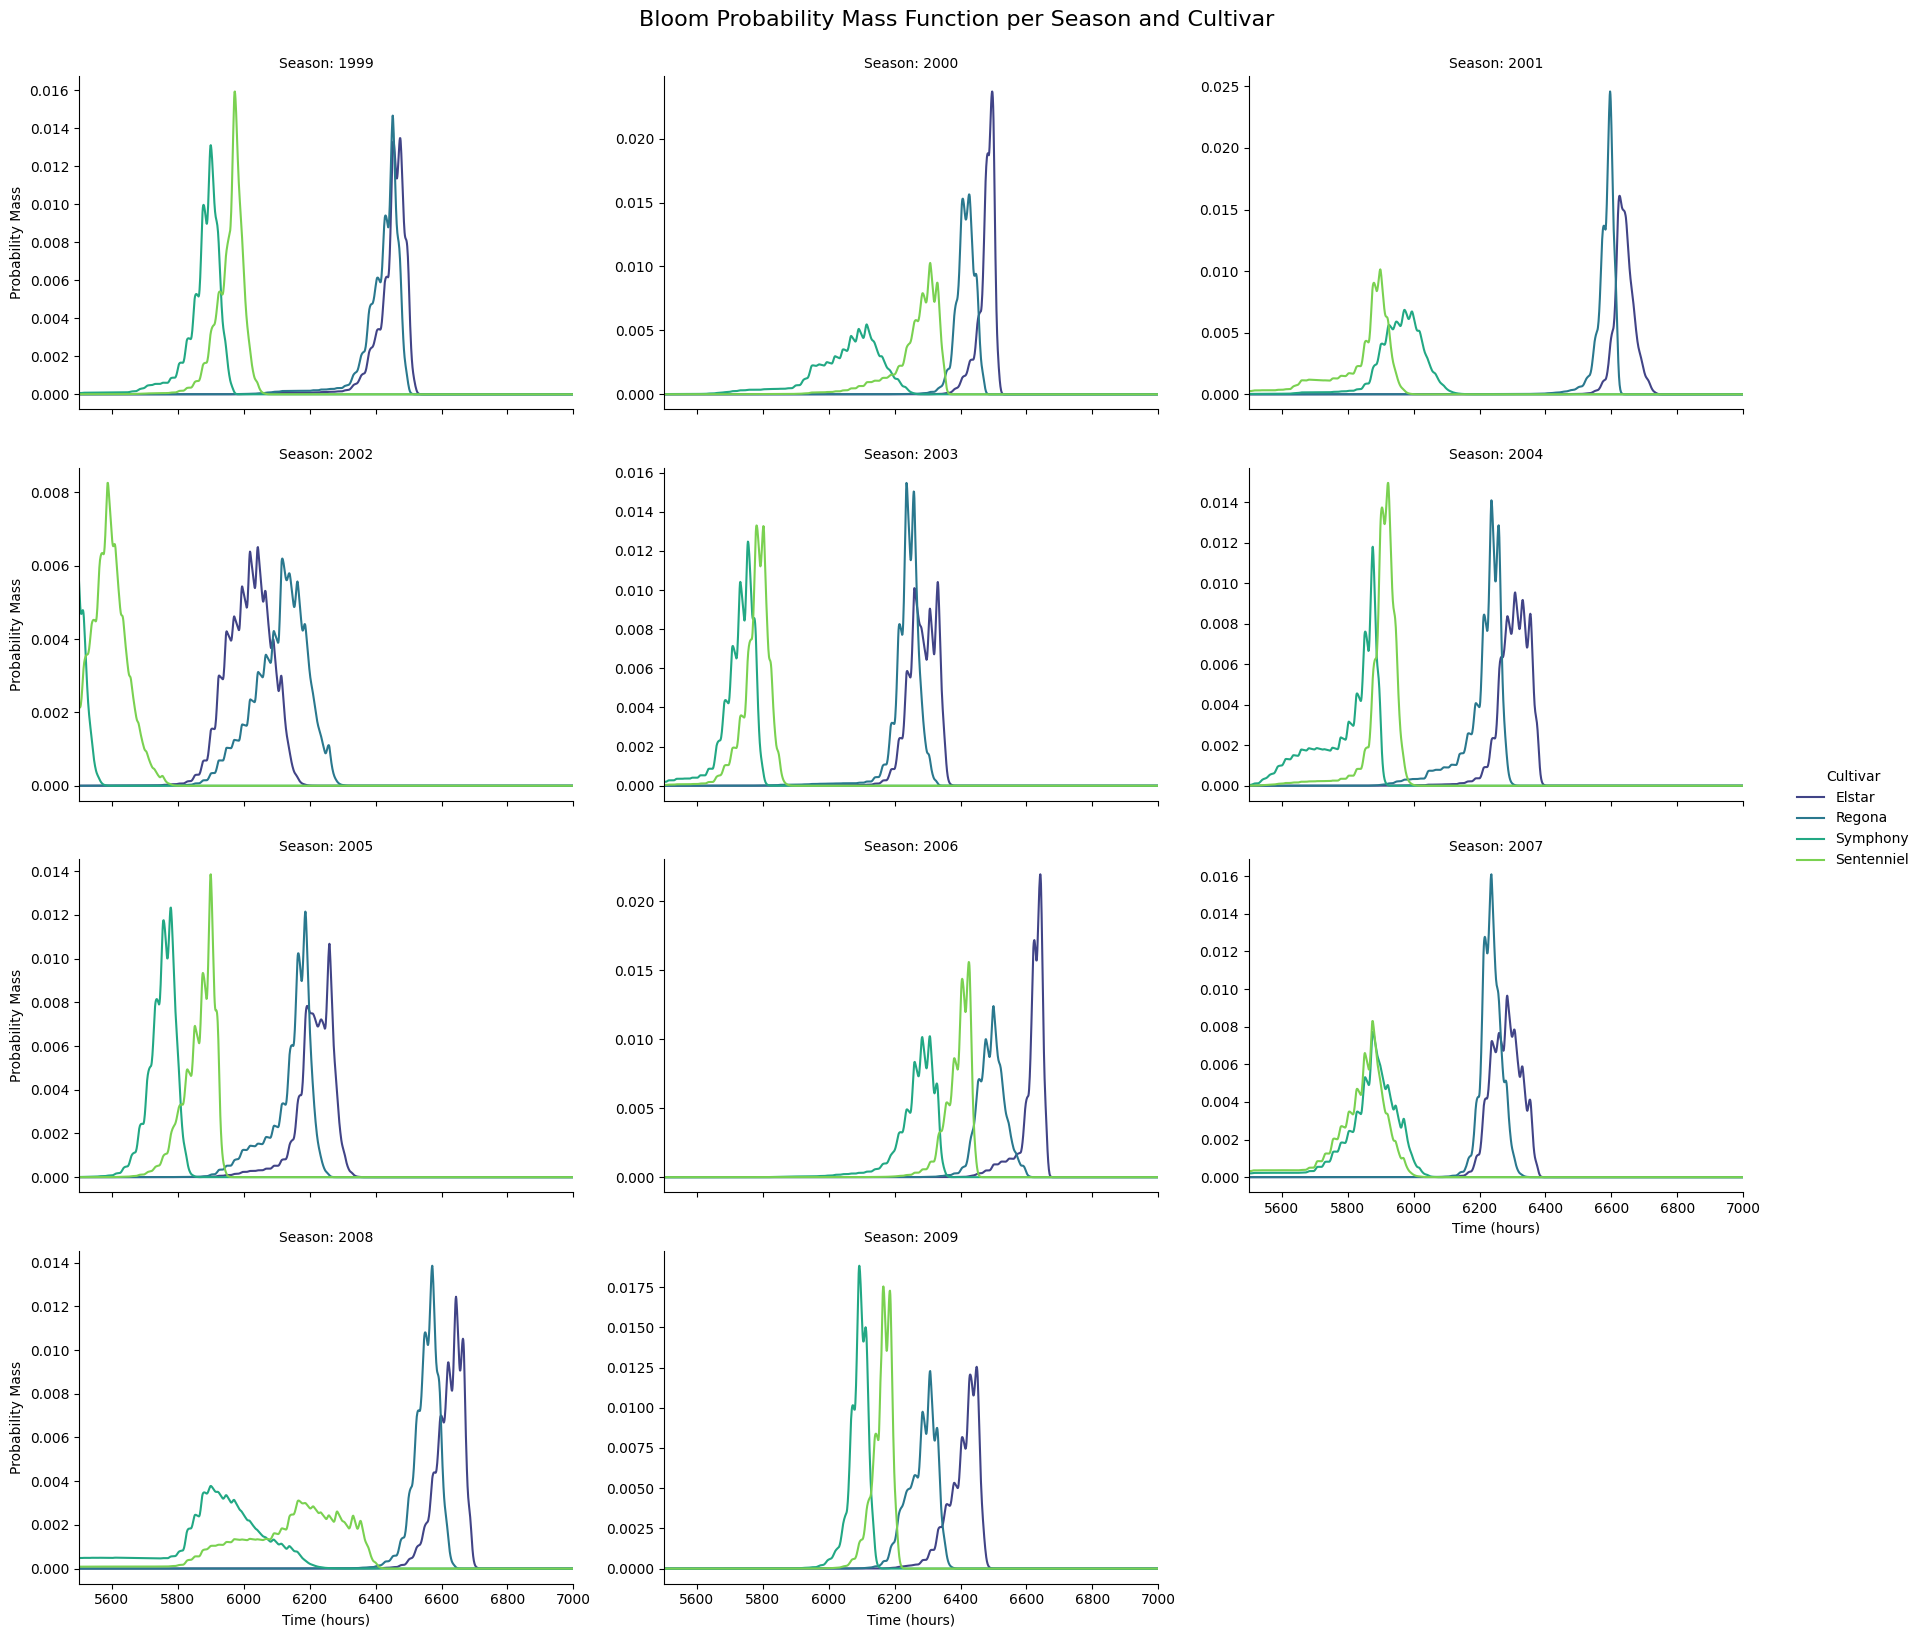

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract PMFs (first sample if multiple samples were drawn)
pmfs = preds['bloom_pmf_pred'][0] # shape (num_seasons, num_hours - 1)
num_seasons = pmfs.shape[0]

# Prepare data for plotting
plot_data = []
for s_idx in range(num_seasons):
    # Get cultivar name using the model's internal index
    cultivar_name = cultivar_names[cultivar_idx[s_idx]]
    year = pheno_data_dummy.iloc[s_idx]['Year'] # Get the year for this season from the original dummy data
    pmf_values = pmfs[s_idx]
    # Adjust hour_values to match the length of pmf_values
    hour_values = times[s_idx][1:] # Take hours from the second element onwards

    # Create a temporary DataFrame for this season's PMF
    season_df = pd.DataFrame({
        'Hour': hour_values,
        'PMF': pmf_values,
        'Cultivar': cultivar_name,
        'Year': str(year) # Convert year to string for categorical hue
    })
    plot_data.append(season_df)

combined_plot_df = pd.concat(plot_data)

# Create a FacetGrid to plot PMF for each season (Year), with cultivars as hue
g = sns.FacetGrid(
    combined_plot_df,
    col='Year',
    col_wrap=3, # Wrap columns after 3 years for better layout
    height=4, aspect=1.5,
    sharex=True, sharey=False
)
g.map_dataframe(sns.lineplot, x='Hour', y='PMF', hue='Cultivar', palette='viridis')
g.add_legend(title='Cultivar')
g.set_axis_labels("Time (hours)", "Probability Mass")
g.set_titles("Season: {col_name}")
plt.xlim(5500, 7000)
g.tight_layout()
plt.suptitle("Bloom Probability Mass Function per Season and Cultivar", y=1.02, fontsize=16) # Adjust suptitle position
plt.show()

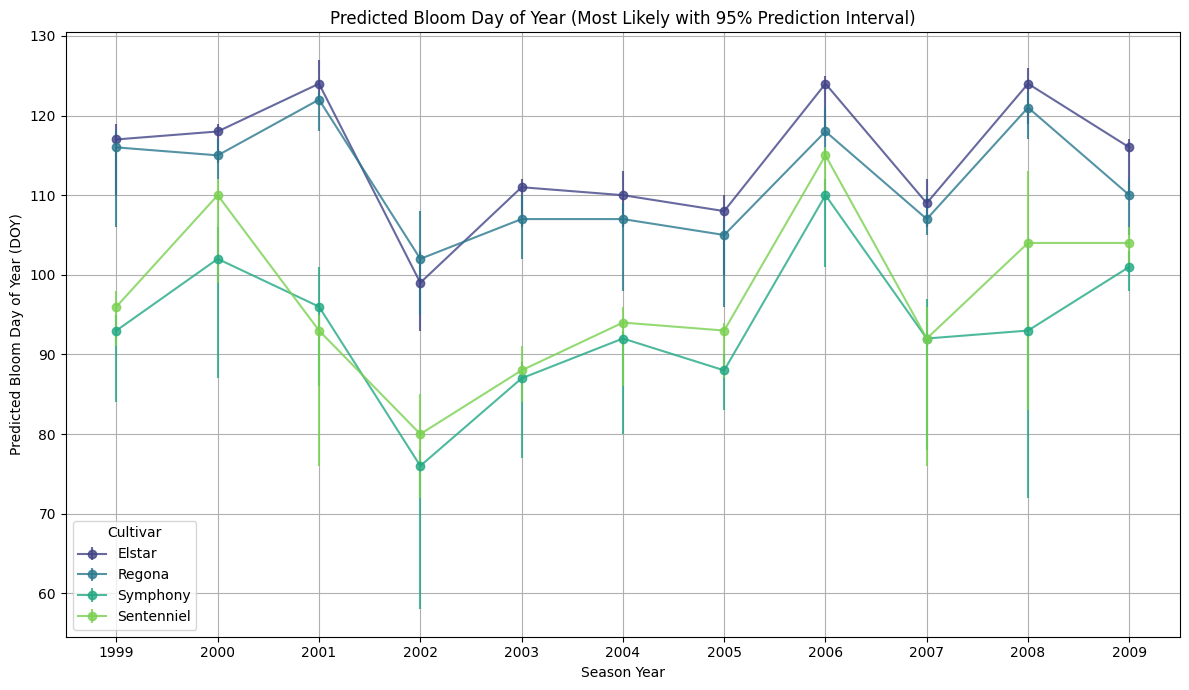

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract predictions
expected_hours_pred = preds["bloom_hour_pred"][0]
most_likely_hours_pred = preds["most_likely_bloom_hour_pred"][0]
pmfs = preds['bloom_pmf_pred'][0] # shape (num_seasons, num_hours - 1)

plot_data = []

# Iterate through each season in the dummy phenology data
for s_idx in range(len(pheno_data_dummy)):
    row = pheno_data_dummy.iloc[s_idx]
    year = int(row['Year'])
    cultivar = row['cultivar_id']
    location = row['location_id']

    # Get the corresponding season DataFrame to map hour index to JDay
    current_season_df = season_dict_for_hierarchical[(location, year)]

    # Convert predicted most likely hour index to integer and then to DOY
    most_likely_hour_idx = int(np.round(most_likely_hours_pred[s_idx]))
    max_actual_idx = len(current_season_df) - 1
    most_likely_hour_idx = min(most_likely_hour_idx, max_actual_idx)
    most_likely_doy = current_season_df.iloc[most_likely_hour_idx]['JDay']

    # Calculate 95% prediction interval from PMF
    pmf_values = pmfs[s_idx]
    hour_values = times[s_idx][1:] # Hours matching pmf_values

    # Ensure PMF sums to 1 (or very close to 1 due to floating point)
    pmf_sum = np.sum(pmf_values)
    if pmf_sum > 0: # Avoid division by zero
        pmf_values = pmf_values / pmf_sum
    else:
        # Handle case where PMF is all zeros (e.g., if no bloom predicted in range)
        # Assign a default wide interval or skip plotting if appropriate
        lower_bound_doy = most_likely_doy - 10 # Example default
        upper_bound_doy = most_likely_doy + 10 # Example default

    cdf = np.cumsum(pmf_values)

    # Find lower and upper bounds for 95% interval (2.5th and 97.5th percentiles)
    # np.where returns a tuple, take the first element (array of indices)
    lower_idx_candidates = np.where(cdf >= 0.025)[0]
    upper_idx_candidates = np.where(cdf >= 0.975)[0]

    lower_bound_hour = hour_values[lower_idx_candidates[0]] if lower_idx_candidates.size > 0 else hour_values[0]
    upper_bound_hour = hour_values[upper_idx_candidates[0]] if upper_idx_candidates.size > 0 else hour_values[-1]

    # Convert bound hours to integer indices for current_season_df
    lower_hour_int = int(np.round(lower_bound_hour))
    upper_hour_int = int(np.round(upper_bound_hour))

    # Ensure indices are within bounds
    lower_hour_int = min(lower_hour_int, max_actual_idx)
    upper_hour_int = min(upper_hour_int, max_actual_idx)

    # Convert to DOY
    lower_bound_doy = current_season_df.iloc[lower_hour_int]['JDay']
    upper_bound_doy = current_season_df.iloc[upper_hour_int]['JDay']

    plot_data.append({
        'Year': year,
        'Cultivar': cultivar,
        'Most_Likely_DOY': most_likely_doy,
        'Lower_Bound_DOY': lower_bound_doy,
        'Upper_Bound_DOY': upper_bound_doy
    })


prediction_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))

# Get unique cultivars for consistent coloring
unique_cultivars = prediction_df['Cultivar'].unique()
palette = sns.color_palette('viridis', n_colors=len(unique_cultivars))
cultivar_colors = {cultivar: palette[i] for i, cultivar in enumerate(unique_cultivars)}

for cultivar in unique_cultivars:
    cultivar_data = prediction_df[prediction_df['Cultivar'] == cultivar]
    years = cultivar_data['Year']
    most_likely_doys = cultivar_data['Most_Likely_DOY']
    lower_bounds = cultivar_data['Lower_Bound_DOY']
    upper_bounds = cultivar_data['Upper_Bound_DOY']

    # yerr needs to be a 2xN array: [lower_errors, upper_errors]
    yerr_lower = most_likely_doys - lower_bounds
    yerr_upper = upper_bounds - most_likely_doys

    plt.errorbar(
        years,
        most_likely_doys,
        yerr=[yerr_lower, yerr_upper],
        fmt='-o', # Line with circle markers at the 'most likely' point
        capsize=0, # Remove caps on the error bars
        label=cultivar,
        color=cultivar_colors[cultivar],
        alpha=0.8
    )

plt.title('Predicted Bloom Day of Year (Most Likely with 95% Prediction Interval)')
plt.xlabel('Season Year')
plt.ylabel('Predicted Bloom Day of Year (DOY)')
plt.xticks(prediction_df['Year'].unique()) # Ensure all years are shown as integer ticks
plt.grid(True)
plt.legend(title='Cultivar')
plt.tight_layout()
plt.show()

In [26]:
#now I want to see, if the pattern can be retrieved by the model. I want the predictions as an input and then run mccm
#extract the most likely bloom date and bring
#preds["most_likely_bloom_hour_pred"]

pheno_data_in = pheno_data_dummy.copy()
#get shape of most likely hour
pheno_data_in['most_likely_hour'] = np.concatenate(preds["most_likely_bloom_hour_pred"])

#get jday corresponding to the hour
def get_jday_from_hour(row):
    year = int(row['Year'])
    location = row['location_id']
    most_likely_hour = int(np.round(row['most_likely_hour']))

    # Get the corresponding season DataFrame
    current_season_df = season_dict_for_hierarchical[(location, year)]

    # Ensure hour index is within bounds
    max_actual_idx = len(current_season_df) - 1
    hour_idx_clipped = min(most_likely_hour, max_actual_idx)

    return current_season_df.iloc[hour_idx_clipped]['JDay']

pheno_data_in['pheno'] = pheno_data_in.apply(get_jday_from_hour, axis=1)
display(pheno_data_in)


#pheno_data_in['most_likely_hour'] = preds["most_likely_bloom_hour_pred"]
#pheno_data_in

,Year,pheno,cultivar_id,species_id,location_id,most_likely_hour
0,1999,117.0,Elstar,Apple,Klein-Altendorf,6474.0
1,1999,116.0,Regona,Apple,Klein-Altendorf,6452.0
2,1999,93.0,Symphony,Sweet Cherry,Klein-Altendorf,5900.0
3,1999,96.0,Sentenniel,Sweet Cherry,Klein-Altendorf,5973.0
4,2000,118.0,Elstar,Apple,Klein-Altendorf,6496.0
5,2000,115.0,Regona,Apple,Klein-Altendorf,6426.0
6,2000,102.0,Symphony,Sweet Cherry,Klein-Altendorf,6115.0
7,2000,110.0,Sentenniel,Sweet Cherry,Klein-Altendorf,6308.0
8,2001,124.0,Elstar,Apple,Klein-Altendorf,6625.0
9,2001,122.0,Regona,Apple,Klein-Altendorf,6596.0


Re-run the calibration, this time only with the pheno, calculated based on the most likely hour

In [27]:
temps, times, bloom_indices, cultivar_idx, location_idx, cultivar_to_species, cultivar_names, species_names, location_names = prepare_seasons_hierarchical(season_dict_for_hierarchical, pheno_data_in)

dat_phenoflex = {
    'temp': temps,
    'times': times,
    'bloom_index': bloom_indices,
    'cultivar_idx': cultivar_idx,
    'cultivar_to_species': cultivar_to_species,
    'Imodel': 0,    # Using the same Imodel as in the predictive run
    'n_species':   int(np.array(cultivar_to_species).max()) + 1,
    'n_cultivars': int(np.array(cultivar_idx).max()) + 1,
    'return_traces': True
}


#prior for chill requirement
apple_yc_prior = 80
cherry_yc_prior = 50
apples_yc_std = cherry_yc_std = 5
apple_zc_mean = 250 # Placeholder, will use actual calculated values from df_apple and df_cherries_pheno
cherry_zc_mean = 250 # Placeholder, will use actual calculated values from df_apple and df_cherries_pheno
apple_zc_std = 20 # Placeholder
cherry_zc_std = 20 # Placeholder

yc_std_among_cultivars = jnp.array(10.0, dtype=jnp.float32)
zc_std_among_cultivars = jnp.array(10.0, dtype=jnp.float32)

yc_offset = jnp.array(0.0, dtype=jnp.float32)
yc_offset_std = jnp.array(1.0, dtype=jnp.float32)
zc_offset = jnp.array(0.0, dtype=jnp.float32)
zc_offset_std = jnp.array(1.0, dtype=jnp.float32)

#to convert priors of the lognormal yc
from numpy import log
def solve_for_log_normal_parameters(mean, variance):
    sigma2 = log(variance/mean**2 + 1)
    mu = log(mean) - sigma2/2
    return (mu, sigma2)

apple_yc_prior_mu, apple_yc_prior_sigma2 = solve_for_log_normal_parameters(apple_yc_prior, apples_yc_std**2)
cherry_yc_prior_mu, cherry_yc_prior_sigma2 = solve_for_log_normal_parameters(cherry_yc_prior, cherry_yc_std**2)

# The FIXED_HIERARCHICAL_PARAMS now only contain the fixed shape parameters
FIXED_PARAMS_FOR_CONDITIONING = dict(
    # Fix all the shape parameters to single values
    E0=4153.5, E1=12888.8, A0=139500.0, A1=2.567e18,
    Tf=4.0, slope=1.6, Tb=4.0, Tu=26.0, Tc=36.0, Delta=4.0,
    k=0.1, s1=0.5,
)

# Define custom priors for the hierarchical parameters that will be sampled
# from these distributions instead of the default ones in the model.
# The species order is ['Apple', 'Sweet Cherry'] as inferred from species_names.
custom_priors = {
    # yc_species: forcing requirement, two species (Apple, Sweet Cherry)
    "yc_species": dist.LogNormal(jnp.array([apple_yc_prior_mu, cherry_yc_prior_mu], dtype=jnp.float32), jnp.array([jnp.sqrt(apple_yc_prior_sigma2), jnp.sqrt(cherry_yc_prior_sigma2)], dtype=jnp.float32)),

    # zc_species: chilling requirement (CP), two species (Apple, Sweet Cherry)
    # Using the calculated means and stds: apple_cp_mean for Apple, cherry_mean for Sweet Cherry
    #"zc_species": dist.Normal(jnp.array([apple_zc_mean, cherry_zc_mean], dtype=jnp.float32), jnp.array([apple_zc_std, cherry_zc_std], dtype=jnp.float32)),
    #"zc_species": dist.unif Normal(jnp.array([apple_zc_mean, cherry_zc_mean], dtype=jnp.float32), jnp.array([apple_zc_std, cherry_zc_std], dtype=jnp.float32)),
    'zc_species' : dist.Uniform(150.0, 350.0),

    # yc_sigma, zc_sigma: variability around species mean, HalfNormal priors
    "yc_sigma": dist.HalfNormal(yc_std_among_cultivars),
    "zc_sigma": dist.HalfNormal(zc_std_among_cultivars),

    # yc_offset, zc_offset: cultivar-specific deviations, Normal priors
    "yc_offset": dist.Normal(yc_offset, yc_offset_std),
    "zc_offset": dist.Normal(zc_offset, zc_offset_std),
}

# Define a wrapper function that passes custom_priors to the model
def phenoflex_model_with_custom_priors(temp, times, cultivar_idx, cultivar_to_species,
                                     bloom_index=None, Imodel=0, deg_celsius=True, return_traces=False,
                                       n_species=None, n_cultivars=None):
    return phenoflex_numpyro_hierarchical(
        temp=temp,
        times=times,
        cultivar_idx=cultivar_idx,
        cultivar_to_species=cultivar_to_species,
        bloom_index=bloom_index,
        Imodel=Imodel,
        deg_celsius=deg_celsius,
        return_traces=return_traces,
        priors=custom_priors, # Pass custom_priors here
        n_species=n_species,       # ← pass through
        n_cultivars=n_cultivars,   # ← pass through
    )

# Condition the wrapper model with fixed parameters
conditioned_model = numpyro.handlers.condition(
    phenoflex_model_with_custom_priors,
    data=FIXED_PARAMS_FOR_CONDITIONING,
)

In [28]:
dat_phenoflex

{'temp': Array([[11.31, 10.67, 10.12, ..., 14.35, 14.35, 14.35],
        [11.31, 10.67, 10.12, ..., 14.35, 14.35, 14.35],
        [11.31, 10.67, 10.12, ..., 14.35, 14.35, 14.35],
        ...,
        [17.04, 16.25, 15.58, ..., 19.68, 19.68, 19.68],
        [17.04, 16.25, 15.58, ..., 19.68, 19.68, 19.68],
        [17.04, 16.25, 15.58, ..., 19.68, 19.68, 19.68]], dtype=float32),
 'times': Array([[0.000e+00, 1.000e+00, 2.000e+00, ..., 8.037e+03, 8.038e+03,
         8.039e+03],
        [0.000e+00, 1.000e+00, 2.000e+00, ..., 8.037e+03, 8.038e+03,
         8.039e+03],
        [0.000e+00, 1.000e+00, 2.000e+00, ..., 8.037e+03, 8.038e+03,
         8.039e+03],
        ...,
        [0.000e+00, 1.000e+00, 2.000e+00, ..., 8.037e+03, 8.038e+03,
         8.039e+03],
        [0.000e+00, 1.000e+00, 2.000e+00, ..., 8.037e+03, 8.038e+03,
         8.039e+03],
        [0.000e+00, 1.000e+00, 2.000e+00, ..., 8.037e+03, 8.038e+03,
         8.039e+03]], dtype=float32),
 'bloom_index': Array([6467, 6443, 5891, 

In [29]:
from numpyro.infer import log_likelihood
import numpyro.handlers as handlers

seeded = handlers.seed(
    handlers.condition(phenoflex_model_with_custom_priors, data=FIXED_PARAMS_FOR_CONDITIONING),
    rng_seed=0
)

# Create a copy of dat_phenoflex and add return_traces': True
dat_phenoflex_with_traces = {**dat_phenoflex, 'return_traces': True}
trace = handlers.trace(seeded).get_trace(**dat_phenoflex_with_traces)

# Print log_prob for each site
for name, site in trace.items():
    # For factor sites (like 'bloom_obs'), the log_prob is the value itself
    # but it might not be stored in `site.get('log_prob')` directly.
    # We can retrieve the log_likelihood of the entire model or a specific part.
    if site['name'] == 'bloom_obs' and site['type'] == 'sample' and site['is_observed']:
        # Recalculate log_liks and sum them to get the bloom_obs log_probability
        # This provides the actual scalar value that 'bloom_obs' contributes
        _z_trace = trace['z_trace']['value'] # Get z_trace from the already run trace
        _bloom_index = dat_phenoflex['bloom_index']
        _zc = trace['zc']['value'] # Now zc is explicitly a deterministic site
        _k = trace['k']['value'] # k is derived from sampled/conditioned params

        _log_liks = jax.vmap(
            lambda z, t, threshold, sharpness: discrete_hazard_loglik(z, t, threshold, sharpness),
            in_axes=(0, 0, 0, None)
        )(_z_trace, _bloom_index, _zc, _k)
        actual_bloom_log_prob = jnp.sum(_log_liks)
        print(f"{name}: actual log_prob = {actual_bloom_log_prob:.3f}")

    elif site['type'] == 'sample' or site['type'] == 'factor':
        lp = site.get('log_prob', None)
        if lp is not None:
            print(f"{name}: log_prob sum = {jnp.sum(lp):.3f}")
        elif 'value' in site:
            # Check if the value is a scalar JAX array (0-dimensional)
            if isinstance(site['value'], jnp.ndarray) and site['value'].ndim == 0:
                print(f"{name} (factor): {site['value'].item():.3f}") # Use .item() to get scalar Python value
            else:
                # For non-scalar arrays, print them directly without scalar formatting
                print(f"{name} (factor): {site['value']}")

E0 (factor): 4153.5
E1 (factor): 12888.8
A0 (factor): 139500.0
A1 (factor): 2.567e+18
Tf (factor): 4.0
slope (factor): 1.6
Tb (factor): 4.0
Tu (factor): 26.0
Tc (factor): 36.0
Delta (factor): 4.0
k (factor): 0.1
s1 (factor): 0.5
yc_species (factor): [68.55062 40.60885]
zc_species (factor): [170.85808 218.79752]
yc_sigma (factor): 13.878
zc_sigma (factor): 23.023
yc_offset (factor): [-1.0147804   1.5873005  -0.01518919 -0.82618   ]
zc_offset (factor): [-0.19817889  0.7955903  -1.2222881  -1.007419  ]
bloom_obs: actual log_prob = -22639.475


In [30]:
#debug
_z_trace = trace['z_trace']['value']
_bloom_index = dat_phenoflex['bloom_index']
_zc = trace['zc_cultivar']['value']  # shape (n_cultivars,) → index per season
_k = 0.2

# Check each season individually
for s in range(_z_trace.shape[0]):
    z   = _z_trace[s]
    bi  = int(_bloom_index[s])
    zc  = float(_zc[int(dat_phenoflex['cultivar_idx'][s])])

    hazards = jax.nn.sigmoid(_k * (z - zc))

    hz_at_bloom  = float(hazards[bi])
    max_hz_before = float(jnp.max(hazards[:bi]))
    z_at_bloom   = float(z[bi])
    z_max        = float(jnp.max(z))

    log_hz   = float(jnp.log(hazards[bi]))
    # Check if any survival term is -inf
    mask = jnp.arange(len(hazards)) < bi
    log_surv = float(jnp.sum(jnp.where(mask, jnp.log1p(-hazards), 0.0)))

    print(f"Season {s:2d} | zc={zc:.1f} | z_max={z_max:.1f} | z@bloom={z_at_bloom:.1f} | "
          f"h@bloom={hz_at_bloom:.4f} | max_h_before={max_hz_before:.4f} | "
          f"log_h={log_hz:.2f} | log_surv={log_surv:.2f}")

Season  0 | zc=166.3 | z_max=1050.2 | z@bloom=268.6 | h@bloom=1.0000 | max_h_before=1.0000 | log_h=0.00 | log_surv=-inf
Season  1 | zc=189.2 | z_max=1000.1 | z@bloom=208.7 | h@bloom=0.9804 | max_h_before=0.9771 | log_h=-0.02 | log_surv=-156.60
Season  2 | zc=195.6 | z_max=1084.0 | z@bloom=188.4 | h@bloom=0.1917 | max_h_before=0.1732 | log_h=-1.65 | log_surv=-3.72
Season  3 | zc=190.7 | z_max=1056.9 | z@bloom=183.8 | h@bloom=0.2035 | max_h_before=0.1793 | log_h=-1.59 | log_surv=-3.21
Season  4 | zc=166.3 | z_max=1103.4 | z@bloom=266.0 | h@bloom=1.0000 | max_h_before=1.0000 | log_h=0.00 | log_surv=-inf
Season  5 | zc=189.2 | z_max=1076.8 | z@bloom=203.5 | h@bloom=0.9459 | max_h_before=0.9406 | log_h=-0.06 | log_surv=-70.97
Season  6 | zc=195.6 | z_max=1126.3 | z@bloom=163.0 | h@bloom=0.0015 | max_h_before=0.0014 | log_h=-6.52 | log_surv=-0.06
Season  7 | zc=190.7 | z_max=1117.8 | z@bloom=188.0 | h@bloom=0.3724 | max_h_before=0.3454 | log_h=-0.99 | log_surv=-10.67
Season  8 | zc=166.3 | z

In [32]:
def run_inference(model, args, rng_key, dat):
    start = time.time()
    sampler = numpyro.infer.NUTS(model,
                                  init_strategy=numpyro.infer.init_to_median(num_samples=500))
    mcmc = numpyro.infer.MCMC(
        sampler,
        num_warmup=args['num_warmup'],
        num_samples=args['num_samples'],
        num_chains=args['num_chains'],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, **dat)
    mcmc.print_summary()
    az_mcmc = az.from_numpyro(mcmc)
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc, mcmc.get_samples(), az_mcmc

# Define args for run_inference
args_phenoflex = {}
args_phenoflex['num_warmup'] = 2000
args_phenoflex['num_samples'] = 2000
args_phenoflex['num_chains'] = 2

# Run the inference
mcmc_phenoflex, mcmc_samples_phenoflex, az_mcmc_phenoflex = run_inference(conditioned_model, args_phenoflex, rng_key, dat_phenoflex)

C:\Users\Lars C\AppData\Local\Temp\ipykernel_26572\2210398815.py:5: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 4000/4000 [2:12:32<00:00,  1.99s/it, 31 steps of size 7.97e-02. acc. prob=0.94]   


ValueError: RESOURCE_EXHAUSTED: Out of memory allocating 2829728000 bytes.

I might need a screening function before running the mcmc, because right now it cannot handle it very well when zc and actual zc are not aligned. The function is much more sensitive than other search algorithms.



Turn table 2 of Santolaria et al. (2026) into a panda
https://doi.org/10.1016/j.agrformet.2026.111138

In [ ]:
# @title
'''
import pandas as pd
import re

data = """
Cultivar	Chill accumulation for endodormancy release			Heat accumulation for flowering
	Chilling Portions	Chilling Hours	Chill Units	GDH
Symphony	37.6 ± 4.5	445 ± 69	685 ± 22	9992 ± 929
Sandon Rose	40.5 ± 1.0	494 ± 15	752 ± 52	9005 ± 1377
Cashmere	41.5 ± 1.0	512 ± 15	788 ± 55	9866 ± 792
Coral Champagne	42.0 ± 1.7	510 ± 23	782 ± 41	8480 ± 2162
Tieton	43.9 ± 4.5	546 ± 76	821 ± 15	9111 ± 1050
Cowiche	45.2 ± 1.8	571 ± 26	856 ± 52	9474 ± 695
Sequoia	47.4 ± 6.0	630 ± 146	930 ± 250	8169 ± 1354
Chelan	48.2 ± 2.8	632 ± 35	941 ± 35	8254 ± 1622
Index	50.9 ± 0.3	672 ± 23	1006 ± 100	7095 ± 1639
Van	51.5 ± 6.4	672 ± 67	1007 ± 24	8359 ± 604
Bing	52.5 ± 0.5	708 ± 57	1036 ± 120	8572 ± 684
Sumele	53.4 ± 2.4	720 ± 19	1057 ± 70	8460 ± 236
Staccato	54.2 ± 1.5	746 ± 98	1084 ± 174	8706 ± 379
Sonata	55.2 ± 4.4	759 ± 129	1104 ± 216	8585 ± 665
Sweetheart	55.3 ± 7.3	774 ± 167	1112 ± 276	8501 ± 1272
Sandra Rose	59.5 ± 1.5	816 ± 108	1186 ± 170	8489 ± 235
Sunburst	60.9 ± 6.4	866 ± 179	1234 ± 262	8535 ± 685
Cristalina	61.4 ± 1.2	854 ± 107	1238 ± 152	8658 ± 222
Selah	62.6 ± 3.9	874 ± 169	1259 ± 226	8277 ± 320
Hartland	62.8 ± 9.0	898 ± 223	1264 ± 304	7837 ± 1110
Skeena	64.9 ± 7.1	914 ± 214	1298 ± 266	7491 ± 472
Sentennial	66.6 ± 5.6	934 ± 210	1330 ± 242	7707 ± 70
"""

# Split data into lines and identify header lines
lines = data.strip().split('\n')
header_line1 = lines[0].split('\t')
header_line2 = lines[1].split('\t')
value_lines = lines[2:]

# Construct column names based on the two-level header
columns = []
current_main_header = ""
main_header_index = 0
for i, h1 in enumerate(header_line1):
    if h1 and h1 != "\t": # Check if header is not empty or just a tab
        current_main_header = h1.strip()
        main_header_index = 0 # Reset for subheaders

    if i < len(header_line2) and header_line2[i]:
        subheader = header_line2[i].strip()
        if subheader:
            if current_main_header and current_main_header != 'Cultivar':
                columns.append(f"{current_main_header} - {subheader}_Mean")
                columns.append(f"{current_main_header} - {subheader}_Std")
            else:
                columns.append(f"{subheader}_Mean") # For Cultivar, it's just the value type
                columns.append(f"{subheader}_Std")
    elif current_main_header == 'Cultivar' and i == 0: # Handle the 'Cultivar' column which has no subheader
         columns.append('Cultivar')

# Correct column names based on the structure provided in the problem description
# This manual step is necessary because the input header structure has empty cells
# that make programmatic parsing difficult without specific rules.
final_columns = [
    'Cultivar',
    'Chill accumulation for endodormancy release - Chilling Portions_Mean',
    'Chill accumulation for endodormancy release - Chilling Portions_Std',
    'Chill accumulation for endodormancy release - Chilling Hours_Mean',
    'Chill accumulation for endodormancy release - Chilling Hours_Std',
    'Chill accumulation for endodormancy release - Chill Units_Mean',
    'Chill accumulation for endodormancy release - Chill Units_Std',
    'Heat accumulation for flowering - GDH_Mean',
    'Heat accumulation for flowering - GDH_Std'
]

parsed_data = []
for line in value_lines:
    parts = line.split('\t')
    row_values = []
    # First element is Cultivar name
    row_values.append(parts[0].strip())

    # The rest are mean ± std values
    for val_str in parts[1:]:
        val_str = val_str.strip()
        if val_str:
            mean_std = val_str.split(' ± ')
            if len(mean_std) == 2:
                row_values.append(float(mean_std[0]))
                row_values.append(float(mean_std[1]))
            else: # Should not happen if data is consistent
                row_values.extend([None, None]) # Placeholder for missing mean/std
        else: # Handle empty string for potentially missing data
            row_values.extend([None, None])

    parsed_data.append(row_values)

# Create DataFrame
df_cherries_pheno = pd.DataFrame(parsed_data, columns=final_columns)

display(df_cherries_pheno.head())
'''


Turn table 2 of Gonzales-Noguer et al. (2024) into a panda
https://doi.org/10.3389/fhort.2023.1217689

In [ ]:
# @title
'''
import pandas as pd
import re

data = """
Cultivar	Usage	Location	Method	Chilling requirements	Heat req	Reference
				CH	CU	CP	GDH
Almey	Crab	USA	E	842				Hauagge and Cummins, 1991
Anna	Dessert	Egypt	E	253	233		5731	El-Agamy et al., 2000
Anna	Dessert	Morocco	E			23.0	8290	El Yaacoubi et al., 2016
Anna	Dessert	USA	E	218				Hauagge and Cummins, 1991
Anoka	Dessert	USA	E	1137				Hauagge and Cummins, 1991
Aporo	Dessert	Spain	S			66.4	7416	Funes et al., 2016
Aporo	Dessert	Spain	S			37.8	9232	Díez-Palet et al., 2019
Arkad Zimnji	Dessert	USA	E	1134				Hauagge and Cummins, 1991
Beacon	Dessert	USA	E	1122				Hauagge and Cummins, 1991
Bellefleur Record	Dessert	USA	E	1145				Hauagge and Cummins, 1991
Beverly Hills	Dessert	USA	E	1152				Hauagge and Cummins, 1991
Blaimont	Dessert	USA	E	1082				Hauagge and Cummins, 1991
Blanquina	Cider	Spain	E	855	1225	78.4	8438	Delgado et al., 2021a
Blanquina	Cider	Spain	S	847	1292	63.3	7940	Delgado et al., 2021b
Boskoop	Dessert	Belgium	S			59.2	4430	Drepper et al., 2020
Brookfield Gala	Dessert	Spain	S			62.5	9230	Funes et al., 2016
Brookfield Gala	Dessert	Spain	S			44.5	9501	Díez-Palet et al., 2019
Challenger	Dessert	Spain	S			43.0	8202	Díez-Palet et al., 2019
Chesnut Crab	Crab	USA	E	838				Hauagge and Cummins, 1991
Chihuahua Gold	Dessert	USA	E	1156				Hauagge and Cummins, 1991
Clara	Cider	Spain	S	842	1296	63.9	9921	Delgado et al., 2021b
Collaos	Cider	Spain	E	911	1304	84.6	10543	Delgado et al., 2021a
Collaos	Cider	Spain	S	818	1240	60.3	9585	Delgado et al., 2021b
Coloradona	Cider	Spain	S	815	1263	63.5	8909	Delgado et al., 2021b
Columbia Crab	Cider	USA	E	890				Hauagge and Cummins, 1991
Cowichan	Crab	USA	E	1044				Hauagge and Cummins, 1991
Cox Orange	Dessert	Belgium	S			79.6	4268	Drepper et al., 2020
Cripps Pink	Dessert	Australia	E	856	1242	73.3		Parkes et al., 2020
Cripps Pink	Dessert	Australia	S			57.0	12330	Darbyshire et al., 2015
Cripps Red	Dessert	Australia	E	662	976	57.0		Parkes et al., 2020
De la Riega	Cider	Spain	E	774	1162	72.2	11770	Delgado et al., 2021a
De la Riega	Cider	Spain	S	830	1260	61.3	8022	Delgado et al., 2021b
Delicious	Dessert	USA	E	1093				Hauagge and Cummins, 1991
Democrat	Dessert	USA	E	1066				Hauagge and Cummins, 1991
Dolgo	Crab	USA	E	966				Hauagge and Cummins, 1991
Dorsett Golden	Dessert	Egypt	E	238	229		5107	El-Agamy et al., 2000
Dorsett Golden	Dessert	USA	E	814				Hauagge and Cummins, 1991
Early McIntosh	Dessert	USA	E	1182				Hauagge and Cummins, 1991
Early Read One	Dessert	Spain	S			65.6	9025	Funes et al., 2016
Early Red One	Dessert	Spain	S			43.6	9349	Díez-Palet et al., 2019
Ecolette	Dessert	Italy	E		866	46.0		Finetto, 2013
Edgar		USA	E	1127				Hauagge and Cummins, 1991
Elstar	Dessert	Spain	E	674	1096	65.6	10649	Delgado et al., 2021a
Elstar	Dessert	Germany	E			50.0	5000	Fernandez et al., 2020
Elstar	Dessert	Germany	S			43	14845	Fernandez et al., 2021
Elstar	Dessert	USA	E	1027				Hauagge and Cummins, 1991
Empire	Dessert	USA	E	1079				Hauagge and Cummins, 1991
Eva	Dessert	Brazil	E			13.0	8082	El Yaacoubi et al., 2016
Freedom	Dessert	USA	E	1213				Hauagge and Cummins, 1991
Fuji	Dessert	Australia	E	908	1307	77.0		Parkes et al., 2020
Fuji	Dessert	Uruguay	E	637	450			Severino et al., 2007
Fuji	Dessert	Brazil	E			24.5	7620	El Yaacoubi et al., 2016
Fuji	Dessert	USA	E	1077				Hauagge and Cummins, 1991
Fuji Chofu 2	Dessert	Spain	S			64.0	9025	Funes et al., 2016
Fuji Chofu 2	Dessert	Spain	S			50.3	7471	Díez-Palet et al., 2019
Fuji Zhen	Dessert	Spain	S			54.4	8190	Díez-Palet et al., 2019
Gala	Dessert	Morocco	S	537	842	44.3	22402	El Yaacoubi et al., 2020
Gala	Dessert	Canada	E	973	875			Guak and Neilsen, 2013
Gala	Dessert	France	E			58.3	8887	El Yaacoubi et al., 2016
Gala	Dessert	Morocco	E			61.2	5894	El Yaacoubi et al., 2016
Gala	Dessert	Brazil	E			25.6	7211	El Yaacoubi et al., 2016
Gala	Dessert	USA	E	1064				Hauagge and Cummins, 1991
Galaxy	Dessert	Australia	E	893	1300	76.7		Parkes et al., 2020
Gloster	Dessert	USA	E	1119				Hauagge and Cummins, 1991
Gold Rush	Dessert	Italy	E		866	46.0		Finetto, 2013
Golden Delicious	Dessert	Italy	E		1025	52.0		Finetto, 2013
Golden Delicious	Dessert	Non-specified	E		1200	50.0		Erez, 2000
Golden Delicious	Dessert	Belgium	S			59.8	4980	Drepper et al., 2020
Golden Delicious	Dessert	France	E			57.4	9964	El Yaacoubi et al., 2016
Golden Delicious	Dessert	Morocco	E			64.2	6865	El Yaacoubi et al., 2016
Golden Delicious	Dessert	USA	E	1050				Hauagge and Cummins, 1991
Golden Gem	Dessert	USA	E	998				Hauagge and Cummins, 1991
Golden Reinders	Dessert	Spain	S			68.4	10273	Funes et al., 2016
Golden Reinders	Dessert	Spain	S			42.4	9239	Díez-Palet et al., 2019
Golden Smoothee	Dessert	Spain	S			65.0	10145	Funes et al., 2016
Golden Smoothee	Dessert	Spain	S			42.8	9690	Díez-Palet et al., 2019
Governor Carr		USA	E	901				Hauagge and Cummins, 1991
Granny Smith	Dessert	Spain	S			63.9	8930	Funes et al., 2016
Granny Smith	Dessert	Spain	S			45.6	8813	Díez-Palet et al., 2019
Granny Smith	Dessert	Australia	E	852	1239	72.2		Parkes et al., 2020
Granny Smith	Dessert	Spain	E	614	1006	59.3	13174	Delgado et al., 2021a
Granny Smith	Dessert	Uruguay	E	583	388			Severino et al., 2007
Granny Smith	Dessert	France	E			43.5	10891	El Yaacoubi et al., 2016
Granny Smith	Dessert	USA	E	1049				Hauagge and Cummins, 1991
Gravenstein	Dessert	USA	E	1118				Hauagge and Cummins, 1991
Hana	Dessert	Italy	E		847	43.0		Finetto, 2013
Hi Early	Dessert	Australia	E	908	1307	77.0		Parkes et al., 2020
Honeygold	Dessert	USA	E	1018				Hauagge and Cummins, 1991
Hume	Dessert	USA	E	1035				Hauagge and Cummins, 1991
Hyslop	Dessert	USA	E	1020				Hauagge and Cummins, 1991
Idared	Dessert	USA	E	1017				Hauagge and Cummins, 1991
Ikorocavka Alaja	Dessert	USA	E	1019				Hauagge and Cummins, 1991
Jeromine	Dessert	Spain	S			43.0	8349	Díez-Palet et al., 2019
Jerseymac	Dessert	USA	E	1120				Hauagge and Cummins, 1991
Joan		USA	E	1001				Hauagge and Cummins, 1991
Jonagold	Dessert	Belgium	S			60.7	4644	Drepper et al., 2020
Jonalicious	Dessert	USA	E	1174				Hauagge and Cummins, 1991
Jonamac	Dessert	USA	E					Hauagge and Cummins, 1991
Julia	Dessert	Italy	E		775	41.0		Finetto, 2013
June Wealthy	Dessert	USA	E	978				Hauagge and Cummins, 1991
Kalei	Dessert	Australia	E	883	1275	75.5		Parkes et al., 2020
Kerr	Crab	USA	E	919				Hauagge and Cummins, 1991
Khashabi		USA	E	694				Hauagge and Cummins, 1991
King Kole		USA	E	960				Hauagge and Cummins, 1991
Lennoxville		USA	E	792				Hauagge and Cummins, 1991
Leyda		USA	E	1009				Hauagge and Cummins, 1991
Liberty	Dessert	USA	E	1053				Hauagge and Cummins, 1991
Limón Montés	Cider	Spain	E	904	1296	84.0	11249	Delgado et al., 2021a
Malling 26	Rootstock	USA	E	1190			6138	Young and Werner, 1985
Malling 7	Rootstock	USA	E	590			4278	Young and Werner, 1985
Malling 9	Rootstock	USA	E	1190			4836	Young and Werner, 1985
Malling 7	Rootstock	USA	E	1151				Hauagge and Cummins, 1991
Malling 9	Rootstock	USA	E	1026				Hauagge and Cummins, 1991
Malling-Merton 106	Rootstock	USA	E	1246				Hauagge and Cummins, 1991
Malling-Merton 106	Rootstock	USA	E	1120			4929	Young and Werner, 1985
Malling-Merton 111	Rootstock	USA	E	1419				Hauagge and Cummins, 1991
Malling-Merton 111	Rootstock	USA	E	1140			5766	Young and Werner, 1985
Manchurian	Dessert	Australia	E	724	1031	61.0		Parkes et al., 2020
Maribor		USA	E	1067				Hauagge and Cummins, 1991
Marin Oufroy	Cider	USA	E	1423				Hauagge and Cummins, 1991
McIntosh	Dessert	USA	E	1086				Hauagge and Cummins, 1991
McLicious	Dessert	USA	E	1090				Hauagge and Cummins, 1991
Medina		USA	E	998				Hauagge and Cummins, 1991
Melba	Dessert	USA	E	1099				Hauagge and Cummins, 1991
Melodie	Dessert	Italy	E		1103	58.0		Finetto, 2013
Melrose	Dessert	USA	E	1063				Hauagge and Cummins, 1991
Milton	Dessert	USA	E	1160				Hauagge and Cummins, 1991
Minjon		USA	E	1290				Hauagge and Cummins, 1991
Minkler	Cider	USA	E	997				Hauagge and Cummins, 1991
Northern Spy	Dessert	USA	E	1228				Hauagge and Cummins, 1991
Oporto		USA	E	1123				Hauagge and Cummins, 1991
Orleans	Dessert	USA	E	1075				Hauagge and Cummins, 1991
Ottawa 7		USA	E	854				Hauagge and Cummins, 1991
Perezosa	Cider	Spain	S	826	1267	64.4	7326	Delgado et al., 2021b
Perico	Cider	Spain	E	891	1273	82.5	11375	Delgado et al., 2021a
Perico	Cider	Spain	S	1.005	1495	72.7	10156	Delgado et al., 2021b
Pink Lady	Dessert	Spain	S			37.8	8065	Díez-Palet et al., 2019
Prima	Dessert	USA	E	1072				Hauagge and Cummins, 1991
Priscilla	Dessert	USA	E	1057				Hauagge and Cummins, 1991
Raxao	Cider	Spain	S	1.005	1495	72.7	11111	Delgado et al., 2021b
Red Chief	Dessert	Spain	S			66.4	9076	Funes et al., 2016
Red Chief	Dessert	Spain	S			40.2	7767	Díez-Palet et al., 2019
Red Chief	Dessert	Uruguay	E	668	406			Severino et al., 2007
Red Crimson Beauty	Dessert	USA	E	962				Hauagge and Cummins, 1991
Red Falls	Dessert	USA	E	1185				Hauagge and Cummins, 1991
Redford		USA	E	1054				Hauagge and Cummins, 1991
Redfree	Dessert	USA	E	1148				Hauagge and Cummins, 1991
Regona	Cider	Spain	E	982	1351	90.2	6512	Delgado et al., 2021a
Rome Beauty	Dessert	USA	E	1163				Hauagge and Cummins, 1991
Rosedale	Crab	USA	E	790				Hauagge and Cummins, 1991
Royal Gala	Dessert	Uruguay	E	667	456			Severino et al., 2007
RS103-110	Dessert	Australia	E	838	1186	70.8		Parkes et al., 2020
Rubinola	Dessert	Italy	E		898	47.0		Finetto, 2013
Solarina	Cider	Spain	E	921	1311	85.2	7897	Delgado et al., 2021a
Spartan	Dessert	USA	E	1117				Hauagge and Cummins, 1991
Starking Delicious	Dessert	United States	S		1234		6993	Ashcroft et al., 1977
Starking Delicious	Dessert	India	S		1208		8893	Mankotia et al., 2004
Summerred	Dessert	USA	E	999				Hauagge and Cummins, 1991
Tasty		USA	E	1020				Hauagge and Cummins, 1991
Teorica	Cider	Spain	S	833	1266	61.7	8646	Delgado et al., 2021b
Toba		USA	E	1194				Hauagge and Cummins, 1991
Topaz	Dessert	Italy	E		1006	52.0		Finetto, 2013
Transcendent	Crab	USA	E	893				Hauagge and Cummins, 1991
Verdialona	Cider	Spain	S	789	1213	59.4	11917	Delgado et al., 2021b
Vienna		USA	E	915				Hauagge and Cummins, 1991
Viking	Dessert	USA	E	1082				Hauagge and Cummins, 1991
Vista Bella	Dessert	USA	E	968				Hauagge and Cummins, 1991
Wealthy	Dessert	USA	E	1169				Hauagge and Cummins, 1991
Wellington	Dessert	USA	E	965				Hauagge and Cummins, 1991
Winter Banana	Dessert	USA	E	1088				Hauagge and Cummins, 1991
Wolf River	Dessert	USA	E	1217				Hauagge and Cummins, 1991
Xuanina	Cider	Spain	E	855	1239	79.9	9690	Delgado et al., 2021a
Xuanina	Cider	Spain	S	836	1278	62.6	9570	Delgado et al., 2021b
"""

lines = data.strip().split('\n')

# Manually define column structure based on the provided header
# This makes parsing more robust to variations in empty cells in the header
column_info = [
    {'name': 'Cultivar', 'type': 'str'},
    {'name': 'Usage', 'type': 'str'},
    {'name': 'Location', 'type': 'str'},
    {'name': 'Method', 'type': 'str'},
    {'name': 'Chilling requirements - CH', 'type': 'num_std'},
    {'name': 'Chilling requirements - CU', 'type': 'num_std'},
    {'name': 'Chilling requirements - CP', 'type': 'num_std'},
    {'name': 'Heat req - GDH', 'type': 'num_std'},
    {'name': 'Reference', 'type': 'str'}
]

# Generate final column names for the DataFrame
final_columns = []
for col in column_info:
    if col['type'] == 'num_std':
        final_columns.append(f"{col['name']}_Mean")
        final_columns.append(f"{col['name']}_Std")
    else:
        final_columns.append(col['name'])

parsed_data = []
for line in lines[2:]: # Skip the two header lines
    parts = line.split('\t')
    row_values = []
    part_idx = 0

    for col_def in column_info:
        if col_def['type'] == 'str':
            value = parts[part_idx].strip() if part_idx < len(parts) else ''
            row_values.append(value if value else None)
            part_idx += 1
        elif col_def['type'] == 'num_std':
            value_str = parts[part_idx].strip() if part_idx < len(parts) else ''
            if value_str:
                match = re.match(r'(\d+\.?\d*)\s*\±\s*(\d+\.?\d*)', value_str)
                if match: # Mean ± Std format
                    row_values.append(float(match.group(1)))
                    row_values.append(float(match.group(2)))
                else: # Single number format
                    row_values.append(float(value_str))
                    row_values.append(None) # No std deviation
            else:
                row_values.append(None) # Mean is NaN
                row_values.append(None) # Std is NaN
            part_idx += 1
    parsed_data.append(row_values)

# Create DataFrame
df_apple = pd.DataFrame(parsed_data, columns=final_columns)

display(df_apple)
'''


In [ ]:
# @title
"""
#filter df_apple for values in cp, drop nan
df_apple = df_apple.dropna(subset=['Chilling requirements - CP_Mean'])
#only consider Method = S
df_apple = df_apple[df_apple['Method'] == 'S']
df_apple
"""

### Estimating Species-Level Chilling Requirements (CP)

In [52]:
# @title
"""
apple_cp_mean = df_apple['Chilling requirements - CP_Mean'].mean()
apples_cp_std_inter_cultivar = df_apple['Chilling requirements - CP_Mean'].std()
cherry_mean = df_cherries_pheno["Chill accumulation for endodormancy release - Chilling Portions_Mean"].mean()
cherry_std = df_cherries_pheno["Chill accumulation for endodormancy release - Chilling Portions_Mean"].std()

print(f"Estimated Apple Mean Chilling Portions (CP): {species_cp_mean:.2f}")
print(f"Estimated Apple Std Chilling Portions (Inter-cultivar variability): {species_cp_std_inter_cultivar:.2f}")
print(f"Estimated Cherry Mean Chilling Portions (CP): {cherry_mean:.2f}")
print(f"Estimated Cherry Std Chilling Portions (Inter-cultivar variability): {cherry_std:.2f}")
"""




Estimated Apple Mean Chilling Portions (CP): 58.36
Estimated Apple Std Chilling Portions (Inter-cultivar variability): 15.63
Estimated Cherry Mean Chilling Portions (CP): 52.64
Estimated Cherry Std Chilling Portions (Inter-cultivar variability): 8.59


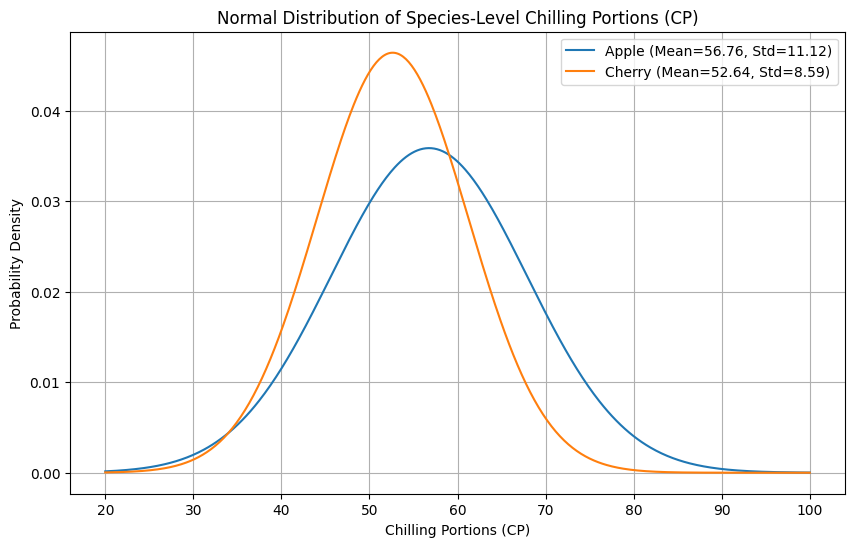

In [54]:
# @title
"""
from scipy.stats import norm

# Define a range for x-values to plot the distributions
x_values = np.linspace(20, 100, 500)

plt.figure(figsize=(10, 6))

# Plot for Apple
plt.plot(x_values, norm.pdf(x_values, apple_cp_mean, apples_cp_std_inter_cultivar), label=f'Apple (Mean={apple_cp_mean:.2f}, Std={apples_cp_std_inter_cultivar:.2f})')

# Plot for Cherry
plt.plot(x_values, norm.pdf(x_values, cherry_mean, cherry_std), label=f'Cherry (Mean={cherry_mean:.2f}, Std={cherry_std:.2f})')

plt.title('Normal Distribution of Species-Level Chilling Portions (CP)')
plt.xlabel('Chilling Portions (CP)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()
"""

In [22]:
# @title
"""
predictive = Predictive(conditioned_model, num_samples=1)
rng_key = jax.random.PRNGKey(0)

preds = predictive(
    rng_key,
    temp=temps,                          # shape (4, N) — one season per cultivar
    times=times,                         # shape (4, N)
    cultivar_idx=cultivar_idx,
    cultivar_to_species=cultivar_to_species,
    bloom_index=None,                    # prediction mode
    Imodel=0,
)

print(preds["bloom_hour_pred"])          # predicted bloom hour per season
print(preds["yc_cultivar"])             # should match your targets above
print(preds["zc_cultivar"])
"""

[[6165.473  6500.9746 5881.2695 6397.7495]]
[[ 55.  75.  85. 100.]]
[[180. 220. 250. 280.]]


In [30]:
# @title
"""
FIXED_PARAMS = dict(
    #yc=-3.24,
    #zc=99.47,
    s1=0.5,
    k = 0.2,
    E0=4153.5,
    E1=12888.8,
    A0=139500.0,
    A1=2.567e18,
    Tf=4.0,
    slope=1.6,
    Tb=4.0,
    Tu=26.0,
    Tc=36.0,
    Delta=4.0,
)

# ── Run ───────────────────────────────────────────────────────────────────────
temps, times, bloom_index, cultivar_idx, cultivar_to_species = prepare_seasons_hazard(
    seasons, KA_bloom, years, cultivar_to_species
)

print(f"Temps shape : {temps.shape}")
print(f"Times shape : {times.shape}")
print(f"Bloom Index  : {bloom_index}")
print(f"Cultivar Index : {cultivar_idx}")
print(f"Cultivar to Species Map : {cultivar_to_species}")


conditioned_model = numpyro.handlers.condition(phenoflex_numpyro_hierarchical, data=FIXED_PARAMS)
predictive        = Predictive(conditioned_model, num_samples=10)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps,
    times=times,
    bloom_index=bloom_index,
    cultivar_idx=cultivar_idx,
    cultivar_to_species=cultivar_to_species,
    Imodel=0,
    return_traces=True,
)
"""


'\nFIXED_PARAMS = dict(\n    #yc=-3.24,\n    #zc=99.47,\n    s1=0.5,\n    k = 0.2,\n    E0=4153.5,\n    E1=12888.8,\n    A0=139500.0,\n    A1=2.567e18,\n    Tf=4.0,\n    slope=1.6,\n    Tb=4.0,\n    Tu=26.0,\n    Tc=36.0,\n    Delta=4.0,\n)\n\n# ── Run ───────────────────────────────────────────────────────────────────────\ntemps, times, bloom_index, cultivar_idx, cultivar_to_species = prepare_seasons_hazard(\n    seasons, KA_bloom, years, cultivar_to_species\n)\n\nprint(f"Temps shape : {temps.shape}")\nprint(f"Times shape : {times.shape}")\nprint(f"Bloom Index  : {bloom_index}")\nprint(f"Cultivar Index : {cultivar_idx}")\nprint(f"Cultivar to Species Map : {cultivar_to_species}")\n\n\nconditioned_model = numpyro.handlers.condition(phenoflex_numpyro_hierarchical, data=FIXED_PARAMS)\npredictive        = Predictive(conditioned_model, num_samples=10)\nrng_key, _        = random.split(random.PRNGKey(1))\n\npreds = predictive(\n    rng_key,\n    temp=temps,\n    times=times,\n    bloom_index